In [2]:
import glob
import os.path as op
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression as LOR
from sklearn.model_selection import KFold
from generalized_contrastive_PCA import gcPCA
from scipy.stats import median_abs_deviation as MAD

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

## Define Helpers and Functions

In [3]:
def reject_outliers(X, m=3, scaling=False):
    """
    Adapted from https://medium.com/@saraswatp/exploring-data-anomalies-rejecting-outliers-with-python-660b1ed6bca6
    Returns a boolean mask where True = 'Keep' and False = 'Outlier'.
    """
    median = np.median(X, axis=0)
    # mad = MAD(X, axis=0, scale='normal')

    if scaling:
        mad = np.median(np.abs(X - median), axis=0) * 1.4826
    else:
        mad = np.median(np.abs(X - median), axis=0)
    
    upper_bound = median + m * mad
    lower_bound = median - m * mad

    mask = (X >= lower_bound) & (X <= upper_bound)

    return mask


def reject_outliers_by_subject_channel(burst_dict, value_key='peak_amp_base', m=3, scaling=False):
    """Compute outlier mask separately within each subject x chennel group.

    Args:
        burst_dict (dictionary): Burst dictionary containing at least:
            - 'subject'
            - 'channel'
            - value_key
        
        value_key (str, optional): Name of the feature on which to reject outliers. Defaults to 'peak_amp_base'.
        m (float, optional): Number of MADs from the median used as the cutoff. Defaults to 3.
        scaling (bool, optional): If True, scale MAD by 1.4826. Defaults to False.
    
    Returns:
        group_mask: ndarray of bool, shape (n_bursts,). Global mask with True = keep, False = outlier.
    """

    values = np.asarray(burst_dict[value_key])
    subjects_arr = np.asarray(burst_dict['subject'])
    channels_arr = np.asarray(burst_dict['channel'])

    n = len(values)
    if not (len(subjects_arr) == n and len(channels_arr) == n):
        raise ValueError(f"'subject', 'channel', and '{value_key}' must have the same length." )
    
    group_mask = np.ones(n, dtype=bool)
    unique_subjects = np.unique(subjects_arr)

    for sub in unique_subjects:
        sub_idx = subjects_arr == sub
        sub_channels = np.unique(channels_arr[sub_idx])

        for ch in sub_channels:
            idx = sub_idx & (channels_arr == ch)

            # Reject within this subject x channel subset
            local_mask = reject_outliers(values[idx], m=m, scaling=scaling)

            # Write local decisions back into full-length mask
            group_mask[idx] = local_mask

    return group_mask

In [4]:
def scaler_fit(X):
    median = np.median(X, axis=0)
    mad = MAD(X, axis=0, scale='normal')
    return median, mad


def scaler_transform(X, median, mad):
    return (X - median) / mad

In [5]:
def get_features_and_labels(gcPC_scores, bursts_dict, type_subs, cols_idx, n_bins, area):
    """
    Function to build the feature matrix and label vector for the logistic regression classifier.
    It takes as input the gcPC scores for all bursts, the bursts dictionary, the indices of the gcPCs
    to consider, the number of bins to use for each gcPC, the number of MADs to use for outlier
    rejection when building trial-level features, and the area to consider (STN or cortical).
    """
    
    max_type_subs = sum(len(np.unique(bursts_dict['trial'][bursts_dict['subject'] == sub])) for sub in type_subs)
    X = np.zeros((max_type_subs, len(cols_idx) * n_bins))
    y = np.zeros(max_type_subs)

    r = 0
    for i in range(len(type_subs)):
        type_sub = type_subs[i]
        
        # compute percentile bin limits using subject bursts only
        subject_bursts_idx = (bursts_dict['subject'] == type_sub) & area
        if np.sum(subject_bursts_idx) == 0:
            print(f'Warning: No bursts found for subject {type_sub} in the selected area ({area}). '
                  'Skipping this subject for percentile bin limit computation.')
            continue

        pc_bin_lims = np.zeros((len(cols_idx), n_bins + 1))
        for col_idx, col in enumerate(cols_idx):
            pc_bin_lims[col_idx, :] = np.percentile(gcPC_scores[subject_bursts_idx, col], np.linspace(0, 100, n_bins + 1))

        # Build trial-level features across all cortex trials
        trials = np.unique(bursts_dict['trial'][(bursts_dict['subject'] == type_sub)])
        for trial in trials:
            burst_idx = area & (bursts_dict['trial'] == trial) & (bursts_dict['subject'] == type_sub)
            label = np.unique(bursts_dict['med'][burst_idx])[0]
            
            row = np.zeros(len(cols_idx) * n_bins, dtype=float)  # Pre-allocate row with zeros for gcPC-bin combinations with no bursts
            for col_idx, col in enumerate(cols_idx):
                for bin in range(n_bins):
                    lower = pc_bin_lims[col_idx, bin]
                    higher = pc_bin_lims[col_idx, bin+1]
                    count = np.sum((gcPC_scores[burst_idx, col] >= lower) &
                                    (gcPC_scores[burst_idx, col] < higher))
                    row[col_idx * n_bins + bin] = count
            X[r, :] = row
            y[r] = 0 if label == 'OFF' else 1
            r += 1

    X = X[:r]
    y = y[:r]

    return X, y

## Data loading

### Channel labels

In [6]:
ch_labels = ['STN_L1', 'STN_L2', 'STN_L3', 'STN_L4', 'STN_R1', 'STN_R2', 'STN_R3', 'STN_R4', 'F3', 'Fz', 'F4', 'C3', 'C4', 'Cz']

### Subject labels

In [7]:
data_dir = '../../data/preprocessed_data/'
out_path = '../../data/derivatives/'
data_files = glob.glob(op.join(data_dir, 'dataClean_step1_*_MED_ON.mat'))
subjects = sorted([x.split('/')[-1].split('_')[3] for x in data_files])
print(subjects)

['s02', 's04', 's05', 's06', 's07', 's08', 's10', 's15', 's16', 's17', 's18']


### Aggregating burst features of the STN and of motor cortex (C3,C4) across all subjects

In [8]:
all_bursts={
    'subject': [],
    'med': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0,132)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

for subject in subjects:
    fname = op.join(out_path, 'beta', f'bursts_{subject}.pickle')
    if op.exists(fname):
        print(subject)
        with open(fname,'rb') as file:  # rb = read binary
            bursts = pickle.load(file)
        
        # stn_c_bursts = boolean containing True for STNs and C3, C4 and False for every other channels
        stn_c_bursts = np.char.startswith(bursts['channel'].astype(str), 'STN') | (bursts['channel']=='C3') | (bursts['channel']=='C4')
        
        # Loads the data from bursts to all_bursts
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]

            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key][stn_c_bursts, :]])

            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key][stn_c_bursts]])

s02
s04
s05
s06
s07
s08
s10
s15
s16
s17
s18


## Perform light pre-processing
* Redefine the trial indices ensuring they're not overlapping between ON and OFF medication - subject-level based
* Convert burst time to ms
* Reject burst outliers based on their peak amplitude

In [9]:
for subject in subjects:
    subj_idx = (all_bursts['subject']==subject)
    off_med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med']=='OFF')])
    max_off_trial = np.max(off_med_trials)
    on_med_idx = subj_idx & (all_bursts['med']=='ON')
    all_bursts['trial'][on_med_idx] = all_bursts['trial'][on_med_idx] + max_off_trial + 1 

In [10]:
burst_times = all_bursts['waveform_times'] * 1000 

In [11]:
outlier_mask = reject_outliers_by_subject_channel(
    all_bursts,
    value_key='peak_amp_base',
    m=3,
    scaling=False
    )

len_mask = len(outlier_mask)

correct_bursts = {
    key: (value[outlier_mask] if len(value) == len_mask else value)
    for key, value in all_bursts.items()
    }

# print(f"Original trials: {len(all_bursts['peak_amp_base'])}")
# print(f"Corrected trials: {len(correct_bursts['peak_amp_base'])}")
# print(f"Removed trials: {len(all_bursts['peak_amp_base']) - len(correct_bursts['peak_amp_base'])}")

### Select bursts corresponding to C3/C4 and all STN contacts

In [12]:
c_idx = (correct_bursts['channel']=='C3') | (correct_bursts['channel']=='C4')
stn_idx = [ch.startswith('STN') for ch in correct_bursts['channel']]

In [13]:
on_idx = (correct_bursts['med']=='ON')
off_idx = (correct_bursts['med']=='OFF')
on_c_idx = c_idx & on_idx
off_c_idx = c_idx & off_idx
on_stn_idx = stn_idx & on_idx
off_stn_idx = stn_idx & off_idx

In [14]:
"""
```scaling_method``` accepts: 
    - 'MAD-based',
    - 'Robust',
    - 'Standard'
"""
scaling_method = 'Standard'

area = stn_idx
scaled_waveforms = np.zeros_like(correct_bursts['waveform'])
for subject in np.unique(correct_bursts['subject']):
    subj_idx = (correct_bursts['subject'] == subject)

    if scaling_method == 'Robust':
        """Perform a modified z-score based on median and IQR"""
        scaler = RobustScaler().fit(correct_bursts['waveform'][subj_idx & area])                # .fit() returns the median and IQR values
        scaled_waveforms[subj_idx, :] = scaler.transform(correct_bursts['waveform'][subj_idx])  # .transform() does the maths.

    elif scaling_method == 'Standard':
        """Perform a z-score based on mean and STD"""
        scaler = StandardScaler().fit(correct_bursts['waveform'][subj_idx & area])              # .fit() returns the mean and STD values
        scaled_waveforms[subj_idx, :] = scaler.transform(correct_bursts['waveform'][subj_idx])  # .transform() does the maths.

    elif scaling_method == 'MAD-based':
        """Perfom a modified z-score based on median and MAD"""
        median, mad = scaler_fit(correct_bursts['waveform'][subj_idx & area])                   # Scaler based on MAD
        scaled_waveforms[subj_idx, :] = scaler_transform(correct_bursts['waveform'][subj_idx], median, mad)

    else:
        raise AttributeError("Wrong scaling method. Valide options are ['MAD-based', 'Robust', 'Standard'].")

## Perfom a gcPCA and scores, coefficients, intercept are saved at the fold-level

### Group-level cross validation: split subjects into train/test groups
* 1/ Perfom a gcPCA
* 2/ Each PC is binned
* 3/ Compute logit on the gcPCA, taking number of PCs and bins as features

In [15]:
"""Parameters definition"""
n_bins = 4              # Number of bins to use for each gcPC
cols = [0, 1, -2, -1]   # List of gcPC columns to consider
m = 3                   # Outlier rejection threshold (in MADs)

subjects = np.array(subjects)
n_splits = len(subjects)
kf = KFold(n_splits=n_splits, shuffle=True, random_state=6)

fold_scores = []
train_fold_scores = []

for fold_idx, (train_s_idx, test_s_idx) in enumerate(kf.split(subjects)):
    train_subs = subjects[train_s_idx]
    test_subs = subjects[test_s_idx]

    # select bursts from training subjects (cortex channels only)
    train_bursts_idx = np.isin(correct_bursts['subject'], train_subs) & area
    train_bursts_on_idx = train_bursts_idx & (correct_bursts['med']=='ON')
    train_bursts_off_idx = train_bursts_idx & (correct_bursts['med']=='OFF')

    # Fit gcPCA on training subjects' bursts
    gcpca_model = gcPCA(method='v4', normalize_flag=False)

    gcpca_model.fit(scaled_waveforms[train_bursts_off_idx, :], scaled_waveforms[train_bursts_on_idx, :])
    all_scores = scaled_waveforms @ gcpca_model.loadings_

    print(f'Fold {fold_idx}: Training on subjects {train_subs}, Testing on subjects {test_subs}')
    
    X_train, y_train = get_features_and_labels(all_scores, correct_bursts, train_subs, cols, n_bins, area)
    X_test, y_test = get_features_and_labels(all_scores, correct_bursts, test_subs, cols, n_bins, area)

    X_train = np.array(X_train)
    X_test = np.array(X_test)
    y_train = np.array(y_train)
    y_test = np.array(y_test)

    model = LOR(max_iter=10_000)
    model = model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    train_score = np.mean(y_train == y_train_pred)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    intercept = model.intercept_
    coefs = model.coef_
    print(f'Fold {fold_idx} Logistic Regression Coefficients:')
    for i, col in enumerate(cols):
        for bin in range(n_bins):
            print(f'  gcPC{col} Bin {bin}:\tCoef =\t {coefs[0][i*n_bins + bin]:.4f}')

    score = np.mean(y_test == y_pred)
    print(f'Fold {fold_idx}: Score = {score:.3f}, Training set score = {train_score:.3f}\n')
    # print('  train_subs:', train_subs)
    # print('  test_subs:', test_subs)
    # print(f'  X_train shape: {X_train.shape}')
    # print(f'  X_test shape: {X_test.shape}\n')
    fold_scores.append(score)
    train_fold_scores.append(train_score)

print(f'Group-level CV: Mean Score = {np.mean(fold_scores):.3f} ± {np.std(fold_scores):.3f}, Train Mean Score = {np.mean(train_fold_scores):.3f}  ± {np.std(train_fold_scores):.3f}')

c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Fold 0: Training on subjects ['s02' 's04' 's05' 's06' 's07' 's08' 's10' 's15' 's17' 's18'], Testing on subjects ['s16']
Fold 0 Logistic Regression Coefficients:
  gcPC0 Bin 0:	Coef =	 -0.0598
  gcPC0 Bin 1:	Coef =	 -0.0070
  gcPC0 Bin 2:	Coef =	 0.0231
  gcPC0 Bin 3:	Coef =	 -0.1307
  gcPC1 Bin 0:	Coef =	 0.0313
  gcPC1 Bin 1:	Coef =	 0.1210
  gcPC1 Bin 2:	Coef =	 0.1959
  gcPC1 Bin 3:	Coef =	 -0.0361
  gcPC-2 Bin 0:	Coef =	 0.1795
  gcPC-2 Bin 1:	Coef =	 0.0981
  gcPC-2 Bin 2:	Coef =	 0.0229
  gcPC-2 Bin 3:	Coef =	 0.1188
  gcPC-1 Bin 0:	Coef =	 -0.2036
  gcPC-1 Bin 1:	Coef =	 -0.2591
  gcPC-1 Bin 2:	Coef =	 -0.2159
  gcPC-1 Bin 3:	Coef =	 -0.0763
Fold 0: Score = 0.902, Training set score = 0.818



c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Fold 1: Training on subjects ['s02' 's05' 's06' 's07' 's08' 's10' 's15' 's16' 's17' 's18'], Testing on subjects ['s04']
Fold 1 Logistic Regression Coefficients:
  gcPC0 Bin 0:	Coef =	 -0.1743
  gcPC0 Bin 1:	Coef =	 -0.0171
  gcPC0 Bin 2:	Coef =	 -0.0176
  gcPC0 Bin 3:	Coef =	 -0.1004
  gcPC1 Bin 0:	Coef =	 0.3226
  gcPC1 Bin 1:	Coef =	 0.3715
  gcPC1 Bin 2:	Coef =	 0.4139
  gcPC1 Bin 3:	Coef =	 0.2661
  gcPC-2 Bin 0:	Coef =	 0.0055
  gcPC-2 Bin 1:	Coef =	 -0.1145
  gcPC-2 Bin 2:	Coef =	 -0.1561
  gcPC-2 Bin 3:	Coef =	 -0.0609
  gcPC-1 Bin 0:	Coef =	 -0.2195
  gcPC-1 Bin 1:	Coef =	 -0.2383
  gcPC-1 Bin 2:	Coef =	 -0.3109
  gcPC-1 Bin 3:	Coef =	 -0.1558
Fold 1: Score = 0.718, Training set score = 0.806



c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


...

Fold 8: Training on subjects ['s02' 's04' 's05' 's07' 's08' 's10' 's15' 's16' 's17' 's18'], Testing on subjects ['s06']
Fold 8 Logistic Regression Coefficients:
  gcPC0 Bin 0:	Coef =	 -0.1998
  gcPC0 Bin 1:	Coef =	 -0.1137
  gcPC0 Bin 2:	Coef =	 -0.0856
  gcPC0 Bin 3:	Coef =	 -0.3008
  gcPC1 Bin 0:	Coef =	 -0.0466
  gcPC1 Bin 1:	Coef =	 0.0715
  gcPC1 Bin 2:	Coef =	 0.1499
  gcPC1 Bin 3:	Coef =	 -0.0795
  gcPC-2 Bin 0:	Coef =	 0.2250
  gcPC-2 Bin 1:	Coef =	 0.0114
  gcPC-2 Bin 2:	Coef =	 0.0400
  gcPC-2 Bin 3:	Coef =	 0.1496
  gcPC-1 Bin 0:	Coef =	 -0.0431
  gcPC-1 Bin 1:	Coef =	 -0.1525
  gcPC-1 Bin 2:	Coef =	 -0.0876
  gcPC-1 Bin 3:	Coef =	 0.0666
Fold 8: Score = 0.375, Training set score = 0.849



c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Fold 9: Training on subjects ['s02' 's04' 's05' 's06' 's07' 's08' 's10' 's15' 's16' 's18'], Testing on subjects ['s17']
Fold 9 Logistic Regression Coefficients:
  gcPC0 Bin 0:	Coef =	 0.1408
  gcPC0 Bin 1:	Coef =	 0.2634
  gcPC0 Bin 2:	Coef =	 0.2362
  gcPC0 Bin 3:	Coef =	 0.1298
  gcPC1 Bin 0:	Coef =	 0.2421
  gcPC1 Bin 1:	Coef =	 0.4888
  gcPC1 Bin 2:	Coef =	 0.3384
  gcPC1 Bin 3:	Coef =	 0.3324
  gcPC-2 Bin 0:	Coef =	 -0.1583
  gcPC-2 Bin 1:	Coef =	 -0.2494
  gcPC-2 Bin 2:	Coef =	 -0.2847
  gcPC-2 Bin 3:	Coef =	 -0.1972
  gcPC-1 Bin 0:	Coef =	 -0.3796
  gcPC-1 Bin 1:	Coef =	 -0.4506
  gcPC-1 Bin 2:	Coef =	 -0.4481
  gcPC-1 Bin 3:	Coef =	 -0.2261
Fold 9: Score = 0.933, Training set score = 0.813



c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Fold 10: Training on subjects ['s02' 's04' 's05' 's06' 's07' 's08' 's10' 's15' 's16' 's17'], Testing on subjects ['s18']
Fold 10 Logistic Regression Coefficients:
  gcPC0 Bin 0:	Coef =	 -0.1625
  gcPC0 Bin 1:	Coef =	 -0.0260
  gcPC0 Bin 2:	Coef =	 -0.0707
  gcPC0 Bin 3:	Coef =	 -0.1063
  gcPC1 Bin 0:	Coef =	 0.2697
  gcPC1 Bin 1:	Coef =	 0.5283
  gcPC1 Bin 2:	Coef =	 0.4097
  gcPC1 Bin 3:	Coef =	 0.3397
  gcPC-2 Bin 0:	Coef =	 0.0486
  gcPC-2 Bin 1:	Coef =	 -0.1129
  gcPC-2 Bin 2:	Coef =	 -0.0745
  gcPC-2 Bin 3:	Coef =	 -0.0043
  gcPC-1 Bin 0:	Coef =	 -0.2718
  gcPC-1 Bin 1:	Coef =	 -0.4081
  gcPC-1 Bin 2:	Coef =	 -0.3417
  gcPC-1 Bin 3:	Coef =	 -0.2190
Fold 10: Score = 1.000, Training set score = 0.825

Group-level CV: Mean Score = 0.741 ± 0.217, Train Mean Score = 0.825  ± 0.023


## Plot mean waveforms for each bin of each gcPC, averaged across subjects (excluding or not the last left out)

C:\Users\Loquet Jeremie\AppData\Local\Temp\ipykernel_81344\3108391744.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(subjects))


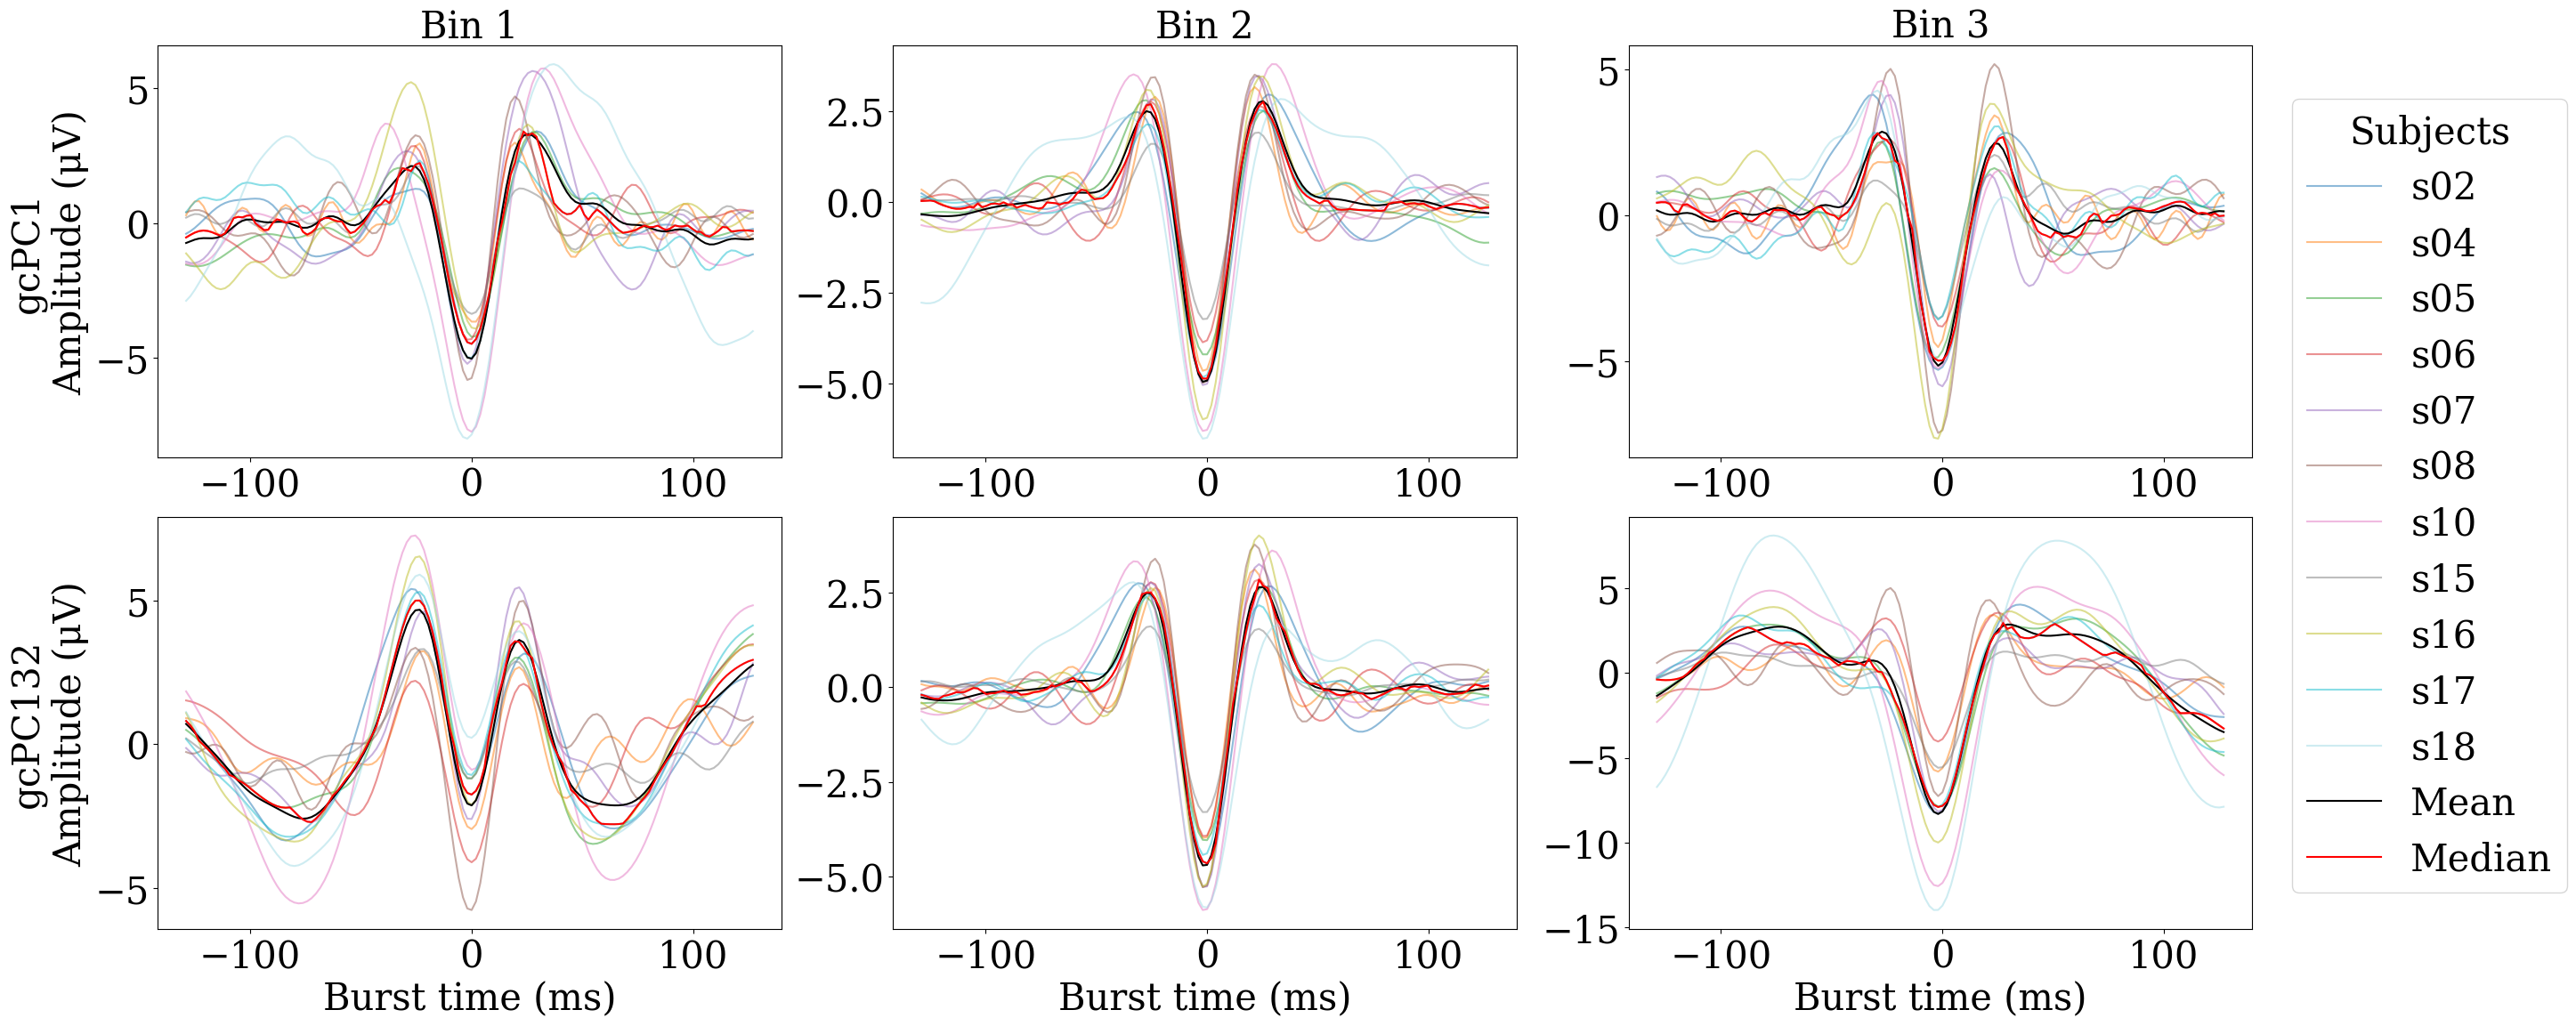

In [32]:
n_bins = 3
cols = [0, -1]

fig, ax = plt.subplots(len(cols), n_bins, figsize=(30, 12))

# Assign colors to subjects
cmap = plt.cm.get_cmap('tab20', len(subjects))
subject_colors = {sub: cmap(i) for i, sub in enumerate(subjects)}

labels = []
mean_waveforms = []  # for all subjects
for col in cols:
    bin_mean_waveforms = []  # reset for each col
    for bin in range(n_bins):
        sub_mean_waveforms = []  # for each bin
        for sub in subjects:  # [subjects != "s18"]
            sub_bursts_idx = np.isin(correct_bursts['subject'], sub) & area
            pc_bin_lims = np.percentile(all_scores[sub_bursts_idx, col], np.linspace(0, 100, n_bins + 1))
            
            if bin == (n_bins - 1):
                lims = (all_scores[:, col] >= pc_bin_lims[bin])
            else:
                lims = (all_scores[:, col] >= pc_bin_lims[bin]) & (all_scores[:, col] < pc_bin_lims[bin + 1])
            
            idx = (correct_bursts['subject'] == sub) & area & lims
            if np.sum(idx) > 0:  # check if there are bursts
                label = str(sub)
                if label not in labels:
                    labels.append(label)

                mean_sub_waveform = np.mean(correct_bursts['waveform'][idx, :], axis=0)
                ax[col, bin].plot(burst_times, mean_sub_waveform, color=subject_colors[sub], label=label, alpha=0.5)
                ax[col, bin].tick_params(axis='both', which='major', labelsize=30)
                sub_mean_waveforms.append(mean_sub_waveform)
        
        if sub_mean_waveforms:
            label_mean, label_median = "Mean", "Median"
            if label_mean not in labels:
                labels.append(label_mean)
            elif label_median not in labels:
                labels.append(label_median)

            overall_mean = np.mean(np.array(sub_mean_waveforms), axis=0)
            ax[col, bin].plot(burst_times, overall_mean, label=label_mean, color='black', alpha=1)
            bin_mean_waveforms.extend(sub_mean_waveforms)

            overall_median = np.median(np.array(sub_mean_waveforms), axis=0)
            ax[col, bin].plot(burst_times, overall_median, label=label_median, color='red', alpha=1)

        ax[0, bin].set_title(f'Bin {bin + 1}', fontsize=30)
        ax[len(cols)-1, bin].set_xlabel('Burst time (ms)', fontsize=30)

    if bin_mean_waveforms:
        mean_waveforms.append(np.mean(np.array(bin_mean_waveforms), axis=0))       

    y_label = "gcPC1\nAmplitude (μV)" if col == 0 else f"gcPC{len(gcpca_model.loadings_[1])}\nAmplitude (μV)"
    ax[col, 0].set_ylabel(y_label, fontsize=30)

# Adjust subplots to make space for legend
fig.subplots_adjust(right=0.85)
fig.legend(labels=labels, bbox_to_anchor=(0.97, 0.89), title='Subjects', title_fontsize=30, fontsize=30)
# fig.suptitle('Mean Burst Waveforms by gcPC Bin - StandardScaling', fontsize=30)
plt.tight_layout(rect=[0, 0, 0.85, 0.97])
plt.savefig('./plots/GL_gcPCA-transformed_MAD-based_waveforms.png', dpi=300)
plt.savefig('./plots/GL_gcPCA-transformed_MAD-based_waveforms.svg', format='svg')
plt.show()

## Plot coefficients for each fold and for s18 
(s18 being the test subject left out in the fold where it is the test subject, and included in the train set for every other fold)


In [ ]:
subjects_coefs = np.load('subjects_coefs.npy', allow_pickle=True).item()
# print(subjects_coefs)

plt.plot(coefs.flatten(),  linestyle='-.', color='black', label='LOOCV')  # linestyle='-', 
plt.plot(subjects_coefs['s18'][0].flatten(), color='red', alpha=0.3, label='Left=s18')
plt.legend(loc="upper left")
plt.title('Logistic Regression Coefficients')
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'subjects_coefs.npy'

## Plot mean burst count as a function of features (gcPCs and percentiles) for Train vs Test (with SEM)

(Text(0, 0.5, 'Burst count'),
 Text(0.5, 0, 'Features'),
 Text(0.5, 1.0, 'Group-level - f(Features) = Burst Count'))

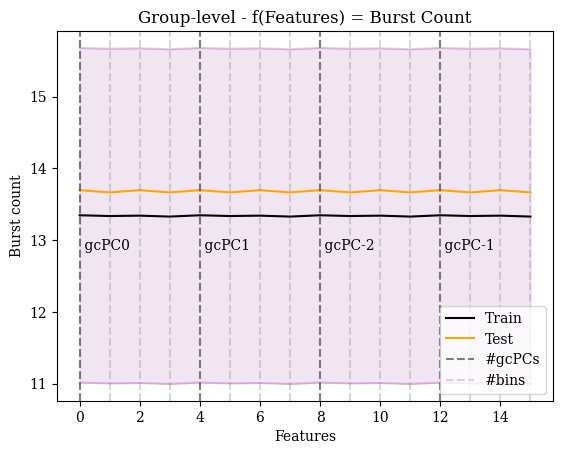

In [ ]:
sem_X_train = np.sqrt(np.std(X_train))
mean_X_train = np.mean(X_train, axis=0)
upper = mean_X_train + sem_X_train
lower = mean_X_train - sem_X_train

y_lim = max(int(np.max(mean_X_train)), int(np.max(np.mean(X_test, axis=0))))

plt.plot(mean_X_train, color='black', label='Train')
plt.plot(upper, color='purple', alpha=0.2)
plt.plot(lower, color='purple', alpha=0.2)
plt.fill_between(range(len(mean_X_train)), lower, upper, color='purple', alpha=0.1)
plt.plot(np.mean(X_test, axis=0), color='orange', label='Test')

for j, col in zip(range(0, len(np.mean(X_test, axis=0)), 4), cols):
    plt.axvline(j, color='black', linestyle='--', alpha=0.5, label="#gcPCs" if j == 0 else None)
    plt.text(j, y_lim-(y_lim/100), f" gcPC{col}")

for j in range(0, len(np.mean(X_test, axis=0))):
    plt.axvline(j, color='gray', linestyle='--', alpha=0.3, label="#bins" if j == 0 else None)

plt.legend()
plt.ylabel("Burst count"), plt.xlabel("Features"), plt.title("Group-level - f(Features) = Burst Count")